In [ ]:
!pip install -q lightgbm catboost shap optuna imbalanced-learn

Libraries

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, precision_recall_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.svm import SVC

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import shap
import joblib

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (9, 6)
sns.set_theme(style="whitegrid")

Upload

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving COVID data.csv to COVID data (1).csv


In [ ]:
df = pd.read_csv("COVID data.csv", low_memory=False)
df.head()

,Age,Age_grouping,Gender,Edu_qualification,Occupation,Study_Discipline,Residence_Districtwise,Residence_Divisionwise,Residence_Administrative,Marital_Status,...,district,division,GENDERCAT,Knowledge,BEH,LRFooD,LRCPANIC,LRQECOHARD,ECONIOMICAL_BURDEN,COMORB
0,29,2,2,5,7,2,1,3,4,2,...,0,1,2,19,12,3,3,3,9,0
1,22,2,1,5,5,2,2,7,4,1,...,0,1,1,16,16,1,3,1,5,1
2,30,3,2,5,7,2,1,3,4,2,...,0,1,2,17,17,1,3,3,7,0
3,21,2,1,5,5,2,3,1,1,1,...,0,0,1,18,17,3,3,1,7,0
4,24,2,1,5,5,2,4,2,1,1,...,0,0,1,17,18,3,3,3,9,0


Dataset Check

In [ ]:
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
missing = df.isnull().sum().sort_values(ascending=False)
display(missing[missing > 0].head(30))

print("\nData types:")
display(df.dtypes.value_counts())

Dataset shape: (10067, 135)

First 5 rows:


,Age,Age_grouping,Gender,Edu_qualification,Occupation,Study_Discipline,Residence_Districtwise,Residence_Divisionwise,Residence_Administrative,Marital_Status,...,district,division,GENDERCAT,Knowledge,BEH,LRFooD,LRCPANIC,LRQECOHARD,ECONIOMICAL_BURDEN,COMORB
0,29,2,2,5,7,2,1,3,4,2,...,0,1,2,19,12,3,3,3,9,0
1,22,2,1,5,5,2,2,7,4,1,...,0,1,1,16,16,1,3,1,5,1
2,30,3,2,5,7,2,1,3,4,2,...,0,1,2,17,17,1,3,3,7,0
3,21,2,1,5,5,2,3,1,1,1,...,0,0,1,18,17,3,3,1,7,0
4,24,2,1,5,5,2,4,2,1,1,...,0,0,1,17,18,3,3,3,9,0



Column names:
['Age', 'Age_grouping', 'Gender', 'Edu_qualification', 'Occupation', 'Study_Discipline', 'Residence_Districtwise', 'Residence_Divisionwise', 'Residence_Administrative', 'Marital_Status', 'Smoker', 'Alcohol_Consumer', 'Current_health', 'Dis_Diabetics', 'Dis_Blood_press', 'Dis_Respiratory', 'Dis_Heart', 'Dis_Kidney', 'Dis_Cancer', 'Dis_Others', 'Dis_TOTAL_comorbidity', 'Naps_at_day', 'Naps_duration', 'From_Dhaka_after_17March', 'From_COVIDcountry_January', 'Social_media_user', 'Social_media_Frequency', 'Source_Social_media', 'Source_Youtube', 'Source_Newpaper', 'Source_TV', 'Source_Website', 'Source_others', 'Source_TOTAL_Info_access', 'LRQ_1.1_Uncomfortable', 'LRQ_1.2_Cant_buy', 'LRQ_1.3_Daily_routine', 'LRQ_1.4_Exercise', 'LRQ_1.5_Going_out', 'LRQ_1.6_Cant_play', 'LRQ_1.7_Household', 'LRQ_1.8_Others', 'LRQ_2_Food_Supply', 'LRQ_3_recession_panic', 'LRQ_4_economic_hardship', 'KRQ_1.1_Cough', 'KRQ_1.2_Touch', 'KRQ_1.3_wild_animal', 'KRQ_1.4_Feces', 'KRQ_1.5_Pets', 'KRQ_1.6_

,0



Data types:


,count
int64,112
object,22
float64,1


Clean Column Names

In [ ]:
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("-", "_")
    .str.replace("/", "_")
)

print(df.columns.tolist())

['Age', 'Age_grouping', 'Gender', 'Edu_qualification', 'Occupation', 'Study_Discipline', 'Residence_Districtwise', 'Residence_Divisionwise', 'Residence_Administrative', 'Marital_Status', 'Smoker', 'Alcohol_Consumer', 'Current_health', 'Dis_Diabetics', 'Dis_Blood_press', 'Dis_Respiratory', 'Dis_Heart', 'Dis_Kidney', 'Dis_Cancer', 'Dis_Others', 'Dis_TOTAL_comorbidity', 'Naps_at_day', 'Naps_duration', 'From_Dhaka_after_17March', 'From_COVIDcountry_January', 'Social_media_user', 'Social_media_Frequency', 'Source_Social_media', 'Source_Youtube', 'Source_Newpaper', 'Source_TV', 'Source_Website', 'Source_others', 'Source_TOTAL_Info_access', 'LRQ_1.1_Uncomfortable', 'LRQ_1.2_Cant_buy', 'LRQ_1.3_Daily_routine', 'LRQ_1.4_Exercise', 'LRQ_1.5_Going_out', 'LRQ_1.6_Cant_play', 'LRQ_1.7_Household', 'LRQ_1.8_Others', 'LRQ_2_Food_Supply', 'LRQ_3_recession_panic', 'LRQ_4_economic_hardship', 'KRQ_1.1_Cough', 'KRQ_1.2_Touch', 'KRQ_1.3_wild_animal', 'KRQ_1.4_Feces', 'KRQ_1.5_Pets', 'KRQ_1.6_Parcels', 'KRQ_

Depression Target

In [ ]:
target_col = "PHQ9_CATEGORY"

print(df[target_col].value_counts(dropna=False))

df["Depression_Target"] = df[target_col].map({1: 0, 2: 1})

df = df.dropna(subset=["Depression_Target"])
df["Depression_Target"] = df["Depression_Target"].astype(int)

print(df["Depression_Target"].value_counts())
print(df["Depression_Target"].value_counts(normalize=True) * 100)

PHQ9_CATEGORY
1    6718
2    3349
Name: count, dtype: int64
Depression_Target
0    6718
1    3349
Name: count, dtype: int64
Depression_Target
0    66.73289
1    33.26711
Name: proportion, dtype: float64


Remove Leakage and Sensitive Columns

In [ ]:
leakage_cols = [
    "PHQ9_1", "PHQ9_2", "PHQ9_3", "PHQ9_4", "PHQ9_5",
    "PHQ9_6", "PHQ9_7", "PHQ9_8", "PHQ9_9",
    "PHQ9_TOTAL", "PHQ9_CATEGORY",
    "Depression_Target"
]

# Remove direct suicide/self-harm related variables if present
sensitive_cols = [
    "Suicide", "SUICIDE", "Suicidal", "suicidal",
    "Suicide_related", "suicide_related"
]

drop_cols = [col for col in leakage_cols + sensitive_cols if col in df.columns]

X = df.drop(columns=drop_cols)
y = df["Depression_Target"]

print("Dropped columns:")
print(drop_cols)

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Dropped columns:
['PHQ9_1', 'PHQ9_2', 'PHQ9_3', 'PHQ9_4', 'PHQ9_5', 'PHQ9_6', 'PHQ9_7', 'PHQ9_8', 'PHQ9_9', 'PHQ9_TOTAL', 'PHQ9_CATEGORY', 'Depression_Target', 'SUICIDE', 'Suicide_related']
Feature shape: (10067, 122)
Target shape: (10067,)


Convert Features to Numeric

In [ ]:
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")

# Remove completely empty columns
empty_cols = X.columns[X.isnull().mean() == 1].tolist()
X = X.drop(columns=empty_cols)

print("Removed empty columns:", empty_cols)
print("Final feature shape:", X.shape)

Removed empty columns: []
Final feature shape: (10067, 122)


Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Train shape: (8053, 122)
Test shape: (2014, 122)

Train target distribution:
Depression_Target
0    66.732895
1    33.267105
Name: proportion, dtype: float64

Test target distribution:
Depression_Target
0    66.73287
1    33.26713
Name: proportion, dtype: float64


EDA

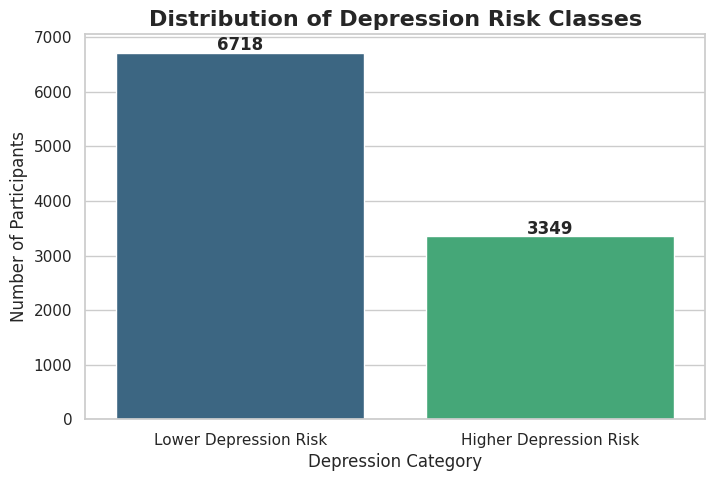

In [ ]:
target_counts = y.value_counts().sort_index()
labels = ["Lower Depression Risk", "Higher Depression Risk"]

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=labels, y=target_counts.values, palette="viridis")
plt.title("Distribution of Depression Risk Classes", fontsize=16, fontweight="bold")
plt.xlabel("Depression Category")
plt.ylabel("Number of Participants")

for i, v in enumerate(target_counts.values):
    plt.text(i, v + 50, str(v), ha="center", fontweight="bold")

plt.show()

EDA — PHQ-9

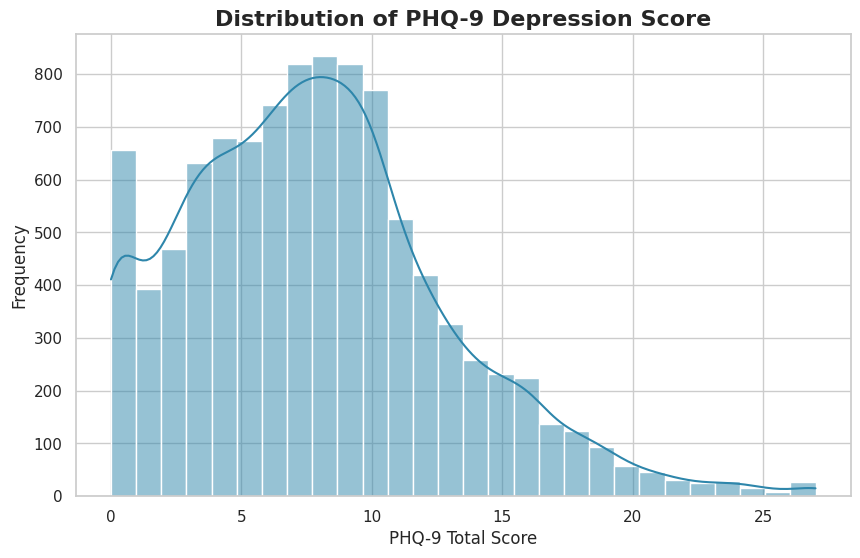

In [ ]:
if "PHQ9_TOTAL" in df.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(df["PHQ9_TOTAL"], bins=28, kde=True, color="#2E86AB")
    plt.title("Distribution of PHQ-9 Depression Score", fontsize=16, fontweight="bold")
    plt.xlabel("PHQ-9 Total Score")
    plt.ylabel("Frequency")
    plt.show()

Mental Health Variables

Available score columns: ['FCV19S_TOTAL', 'ISI_TOTAL', 'Knowledge', 'Knowdlge', 'BEH', 'behavior', 'ECONIOMICAL_BURDEN', 'COMORB', 'Dis_TOTAL_comorbidity']


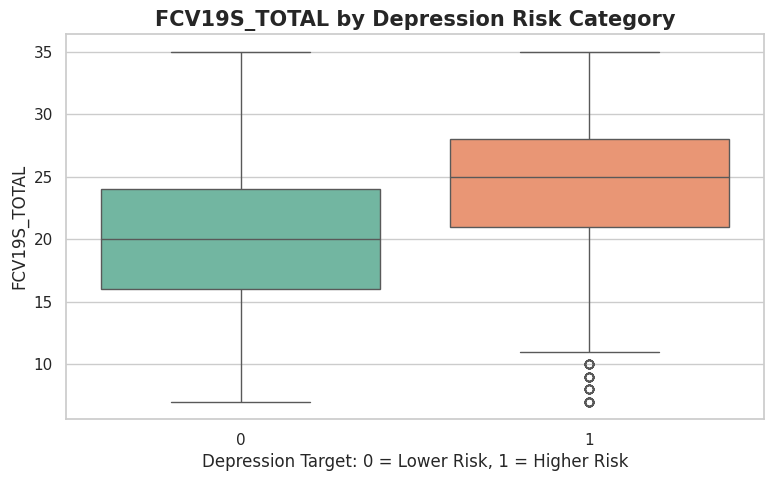

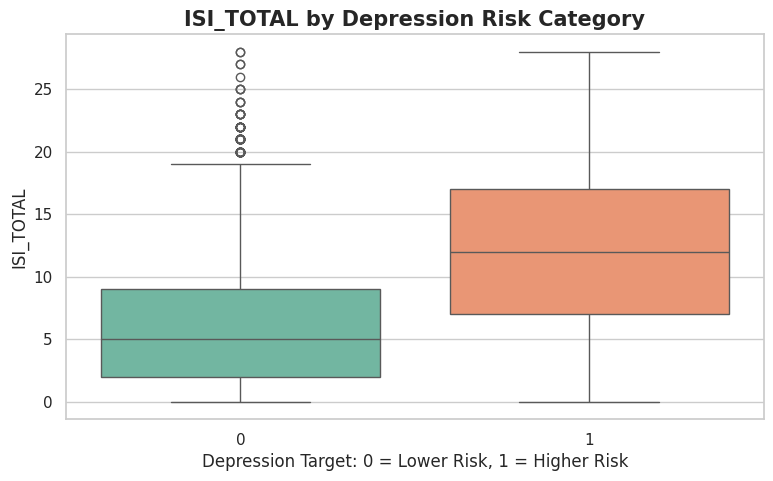

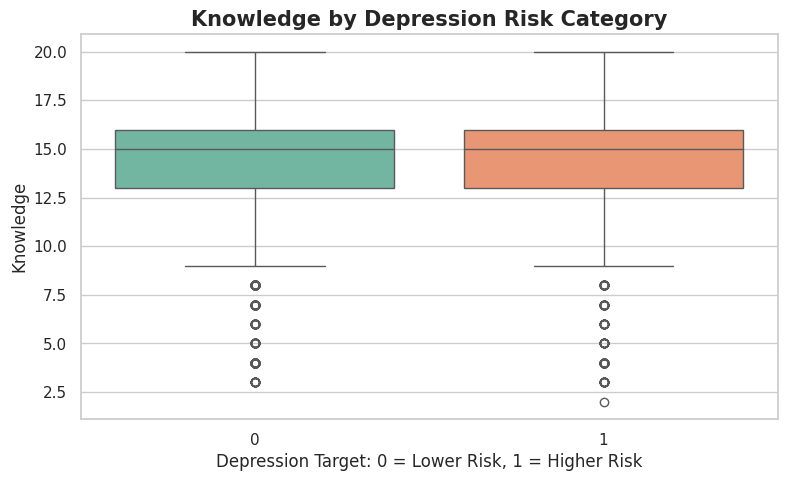

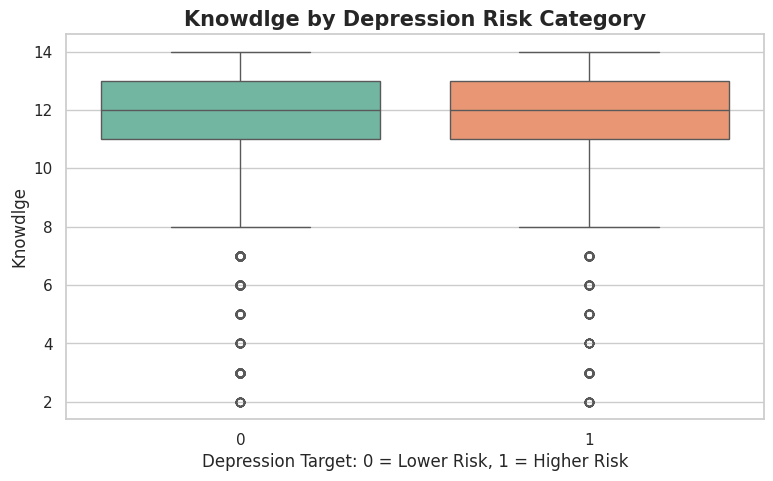

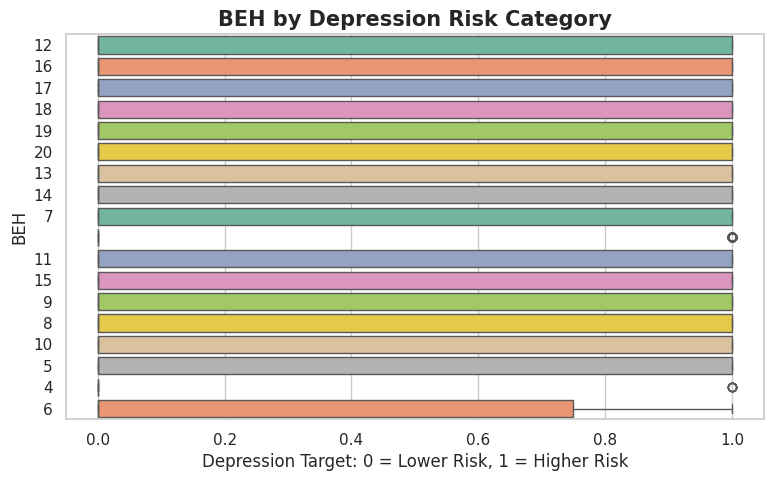

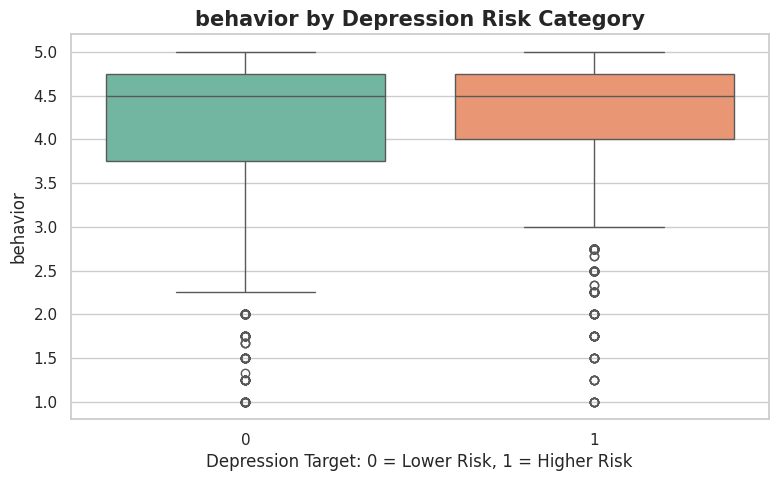

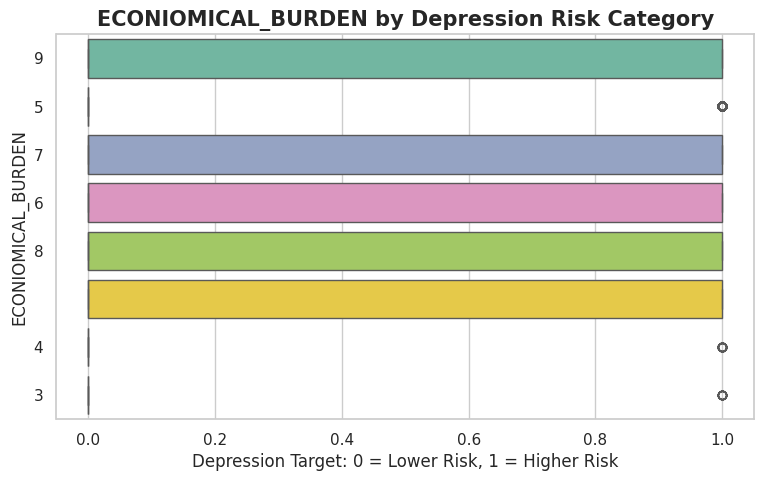

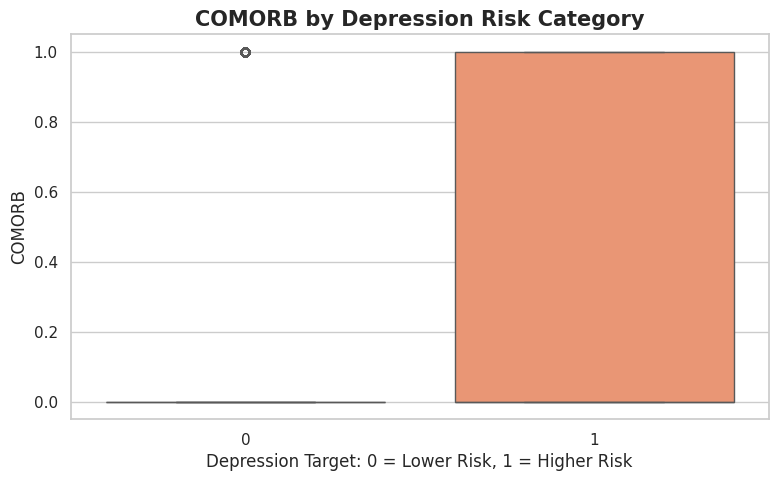

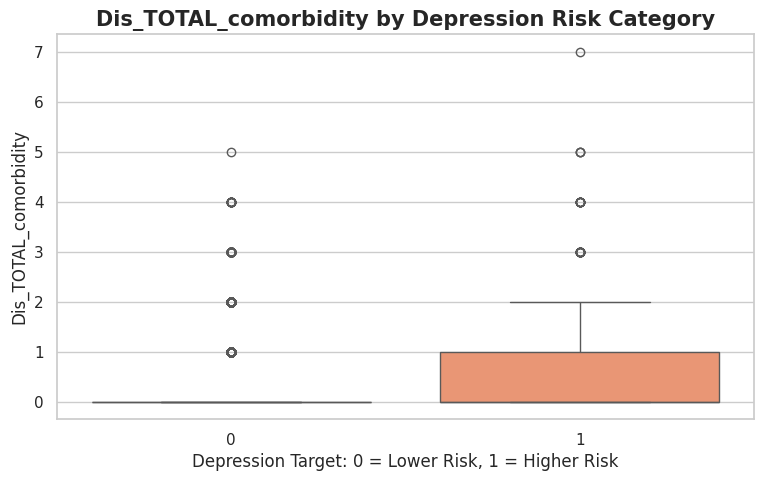

In [ ]:
possible_score_cols = [
    "FCV19S_TOTAL", "ISI_TOTAL", "Knowledge", "Knowdlge",
    "BEH", "behavior", "ECONIOMICAL_BURDEN",
    "COMORB", "Dis_TOTAL_comorbidity"
]

score_cols = [col for col in possible_score_cols if col in df.columns]

print("Available score columns:", score_cols)

for col in score_cols:
    plt.figure(figsize=(9, 5))
    sns.boxplot(data=df, x="Depression_Target", y=col, palette="Set2")
    plt.title(f"{col} by Depression Risk Category", fontsize=15, fontweight="bold")
    plt.xlabel("Depression Target: 0 = Lower Risk, 1 = Higher Risk")
    plt.ylabel(col)
    plt.show()

In [ ]:
important_score_cols = []

for col in ["FCV19S_TOTAL", "ISI_TOTAL", "Knowledge", "Knowdlge", "BEH", "behavior", "ECONIOMICAL_BURDEN", "COMORB"]:
    if col in df.columns:
        important_score_cols.append(col)

print("Available important score columns:", important_score_cols)

Available important score columns: ['FCV19S_TOTAL', 'ISI_TOTAL', 'Knowledge', 'Knowdlge', 'BEH', 'behavior', 'ECONIOMICAL_BURDEN', 'COMORB']


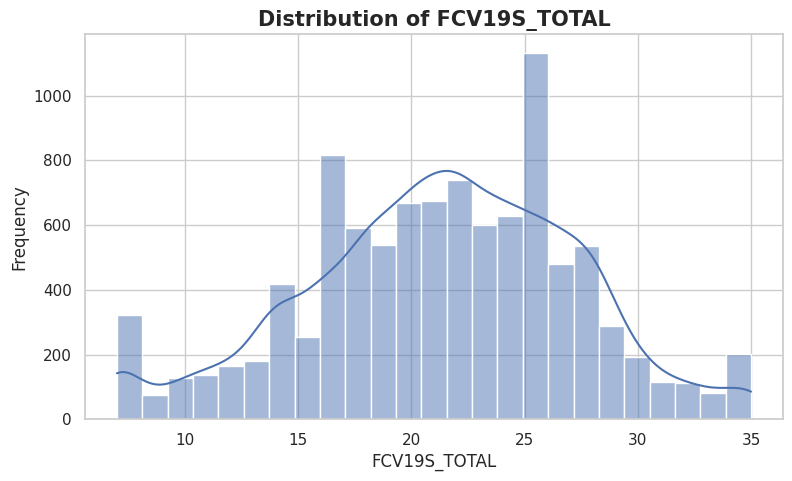

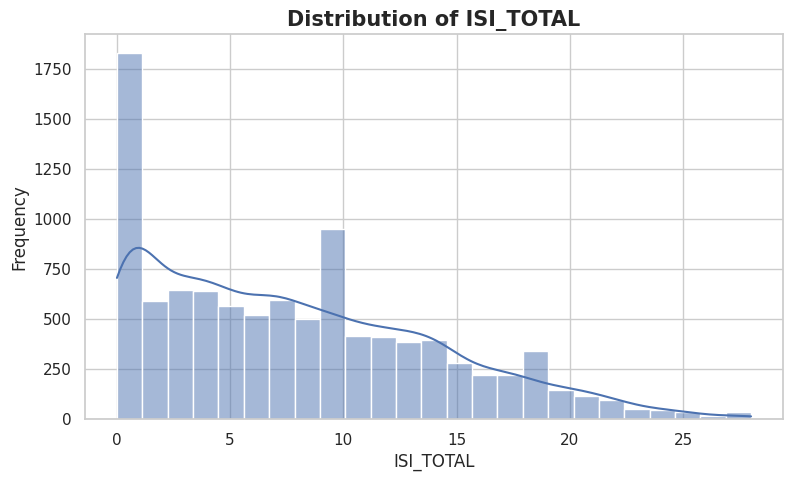

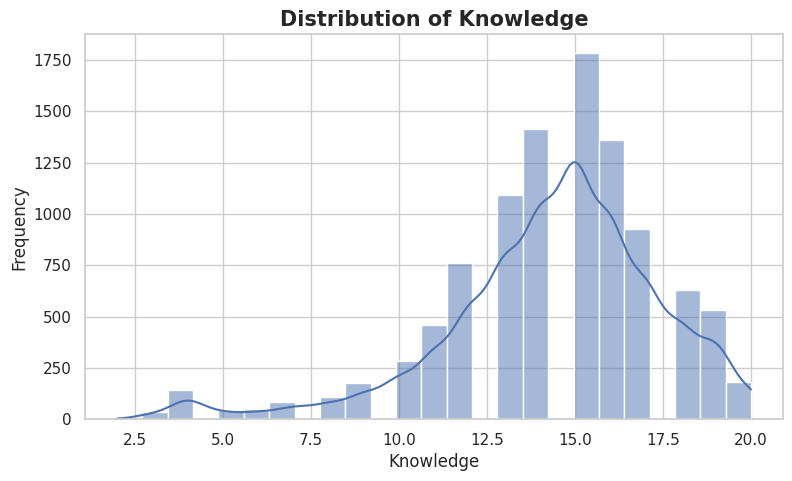

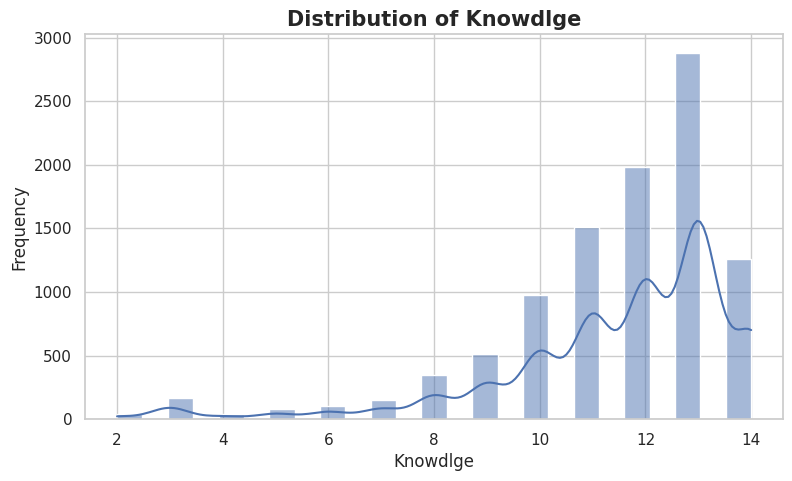

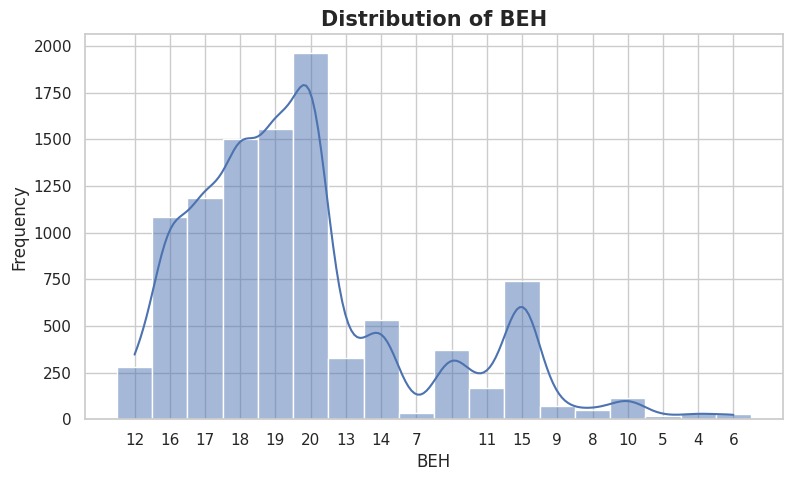

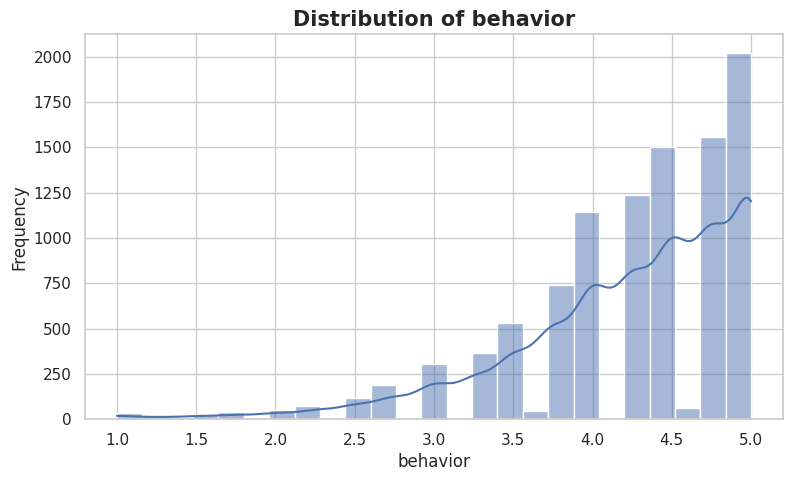

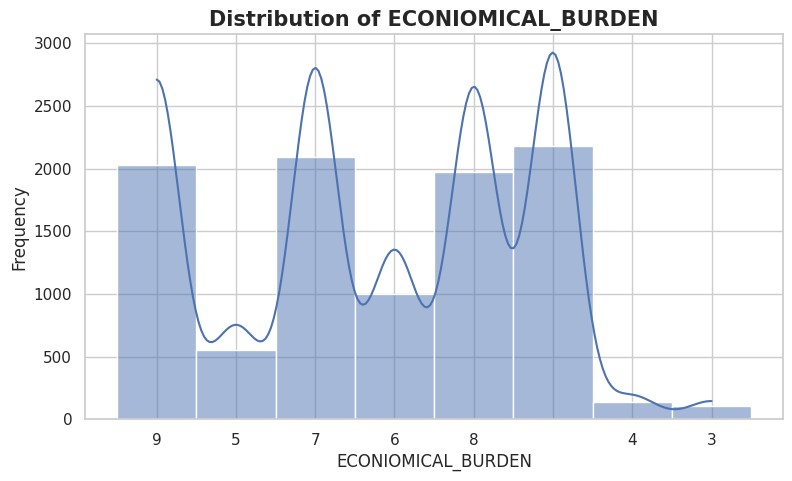

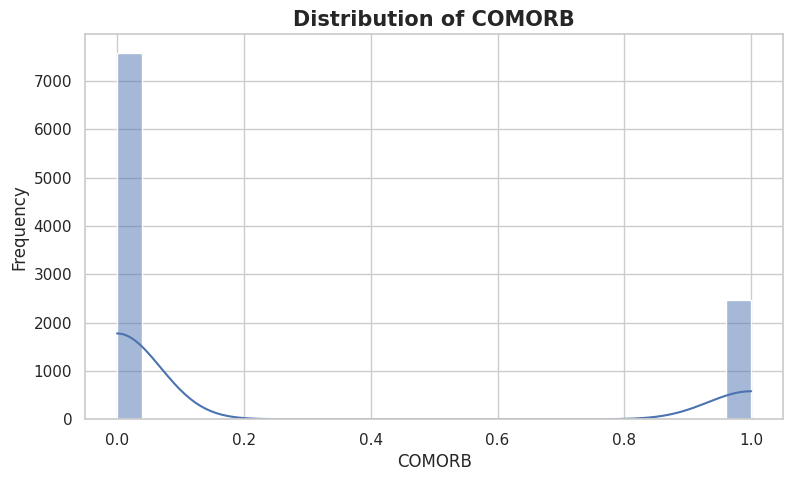

In [ ]:
for col in important_score_cols:
    plt.figure(figsize=(9, 5))
    sns.histplot(df[col], bins=25, kde=True)
    plt.title(f"Distribution of {col}", fontsize=15, fontweight="bold")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

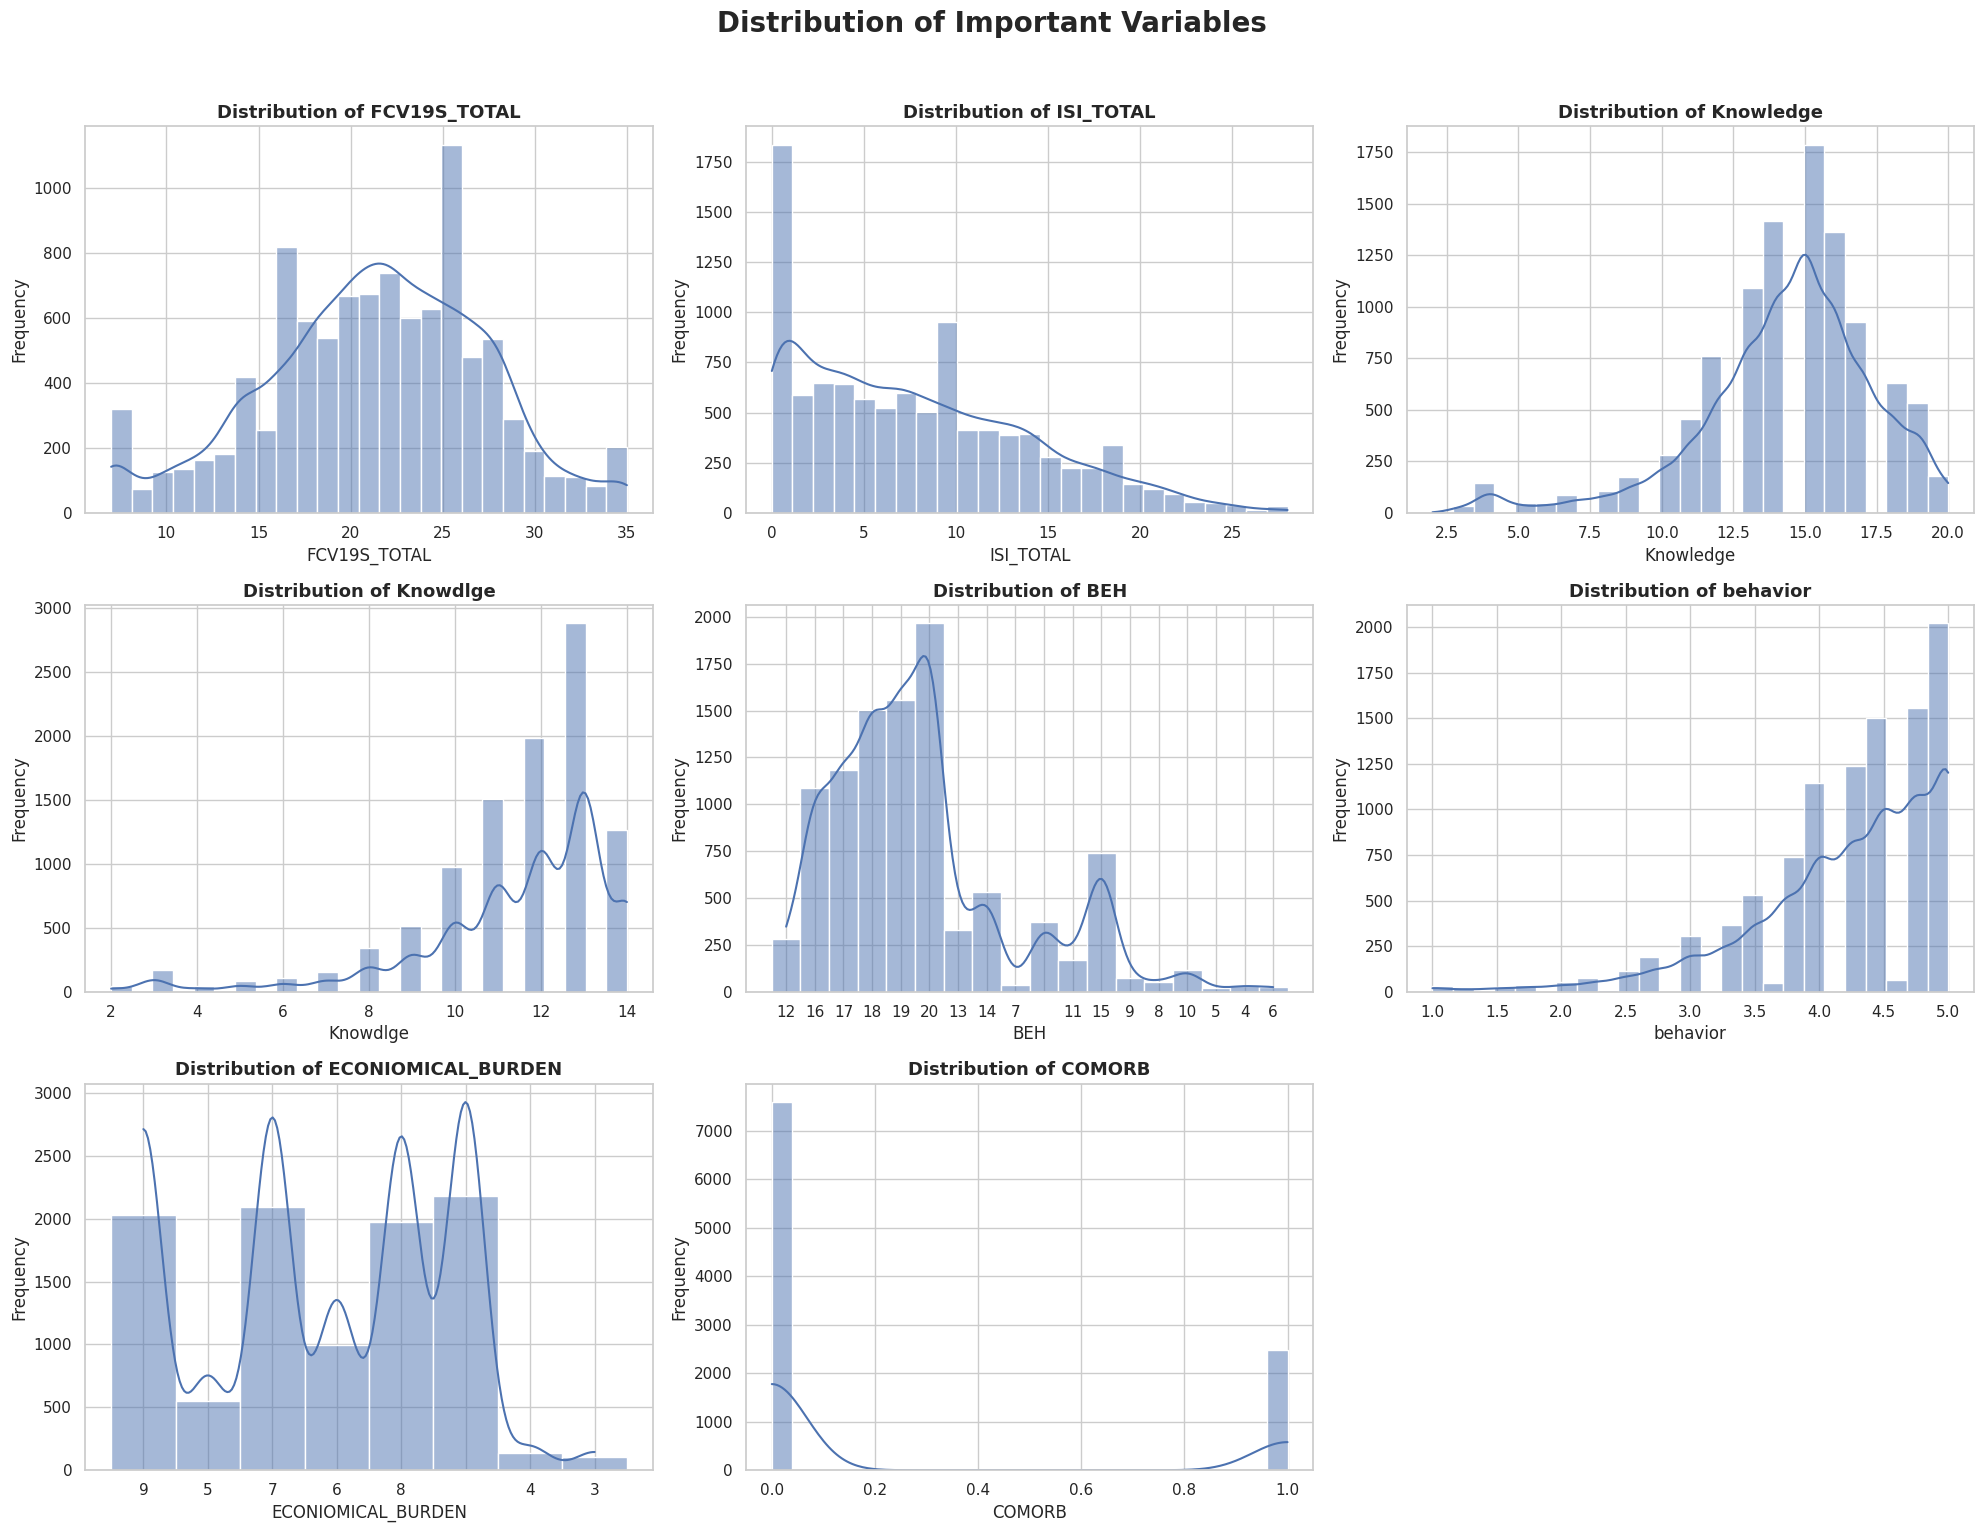

In [ ]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

n_cols = 3
n_rows = math.ceil(len(important_score_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(20, 5 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(important_score_cols):
    sns.histplot(
        data=df,
        x=col,
        bins=25,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(
        f"Distribution of {col}",
        fontsize=13,
        fontweight="bold"
    )
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    "Distribution of Important Variables",
    fontsize=20,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

plt.savefig(
    "all_important_variable_distributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Pipeline for Classical ML

In [ ]:
numeric_features = X.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features)
    ]
)

Classical ML Models

In [ ]:
classic_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=600,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=600,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=800,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=-1,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "CatBoost": CatBoostClassifier(
        iterations=800,
        learning_rate=0.03,
        depth=6,
        loss_function="Logloss",
        eval_metric="AUC",
        verbose=0,
        random_seed=RANDOM_STATE
    ),

    "SVM": SVC(
        kernel="rbf",
        probability=True,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )
}

Train Classical Models

In [ ]:
classic_results = []
trained_classic_models = {}

for name, model in classic_models.items():
    print(f"\nTraining {name}...")

    clf = ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("model", model)
    ])

    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]

    result = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

    classic_results.append(result)
    trained_classic_models[name] = clf

    print(classification_report(y_test, y_pred))

classic_results_df = pd.DataFrame(classic_results).sort_values("ROC-AUC", ascending=False)
display(classic_results_df)


Training Logistic Regression...
              precision    recall  f1-score   support

           0       0.84      0.75      0.79      1344
           1       0.59      0.70      0.64       670

    accuracy                           0.74      2014
   macro avg       0.71      0.73      0.72      2014
weighted avg       0.75      0.74      0.74      2014


Training Random Forest...
              precision    recall  f1-score   support

           0       0.80      0.86      0.83      1344
           1       0.67      0.57      0.61       670

    accuracy                           0.76      2014
   macro avg       0.73      0.71      0.72      2014
weighted avg       0.76      0.76      0.76      2014


Training Extra Trees...
              precision    recall  f1-score   support

           0       0.80      0.85      0.83      1344
           1       0.66      0.58      0.62       670

    accuracy                           0.76      2014
   macro avg       0.73      0.72      0.72

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
2,Extra Trees,0.760675,0.658249,0.583582,0.618671,0.820939
4,CatBoost,0.756207,0.666048,0.535821,0.593879,0.820018
1,Random Forest,0.761668,0.666667,0.567164,0.612903,0.819216
3,LightGBM,0.758689,0.672932,0.534328,0.595674,0.818159
0,Logistic Regression,0.736346,0.586767,0.701493,0.639021,0.805777
5,SVM,0.744786,0.616418,0.616418,0.616418,0.797853


Train-Test-Validation Split for Transformer

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# First split: train/test already may exist
# If X_train, X_test, y_train, y_test already exist, run from here:

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_tr_np = imputer.fit_transform(X_tr)
X_val_np = imputer.transform(X_val)
X_test_np = imputer.transform(X_test)

X_tr_np = scaler.fit_transform(X_tr_np)
X_val_np = scaler.transform(X_val_np)
X_test_np = scaler.transform(X_test_np)

import torch

X_tr_tensor = torch.tensor(X_tr_np, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_np, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_np, dtype=torch.float32)

y_tr_tensor = torch.tensor(y_tr.values, dtype=torch.float32).view(-1, 1)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

print("Train:", X_tr_tensor.shape)
print("Validation:", X_val_tensor.shape)
print("Test:", X_test_tensor.shape)

Train: torch.Size([6442, 122])
Validation: torch.Size([1611, 122])
Test: torch.Size([2014, 122])


Dataset and Loader

In [ ]:
from torch.utils.data import Dataset, DataLoader

class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


batch_size = 128

train_dataset = TabularDataset(X_tr_tensor, y_tr_tensor)
val_dataset = TabularDataset(X_val_tensor, y_val_tensor)
test_dataset = TabularDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

FT-Transformer Model

In [ ]:
import torch.nn as nn

class FTTransformer(nn.Module):
    def __init__(
        self,
        n_features,
        d_token=32,
        n_heads=4,
        n_layers=2,
        dropout=0.20
    ):
        super().__init__()

        self.n_features = n_features
        self.d_token = d_token

        self.feature_weight = nn.Parameter(torch.randn(n_features, d_token) * 0.02)
        self.feature_bias = nn.Parameter(torch.zeros(n_features, d_token))

        self.cls_token = nn.Parameter(torch.randn(1, 1, d_token) * 0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_token,
            nhead=n_heads,
            dim_feedforward=d_token * 4,
            dropout=dropout,
            batch_first=True,
            activation="gelu"
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers
        )

        self.head = nn.Sequential(
            nn.LayerNorm(d_token),
            nn.Linear(d_token, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        tokens = x.unsqueeze(-1) * self.feature_weight + self.feature_bias

        batch_size = x.shape[0]
        cls_tokens = self.cls_token.repeat(batch_size, 1, 1)

        tokens = torch.cat([cls_tokens, tokens], dim=1)

        encoded = self.transformer(tokens)
        cls_output = encoded[:, 0]

        logits = self.head(cls_output)
        return logits

Train Transformer

In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

n_features = X_tr_tensor.shape[1]

ft_transformer_model = FTTransformer(
    n_features=n_features,
    d_token=32,
    n_heads=4,
    n_layers=2,
    dropout=0.20
).to(device)

# Class imbalance handling
positive_count = y_tr.sum()
negative_count = len(y_tr) - positive_count
pos_weight_value = negative_count / positive_count

pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(
    ft_transformer_model.parameters(),
    lr=0.0003,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)

epochs = 50
patience = 7

best_val_auc = 0
best_model_state = None
no_improve = 0

train_losses = []
val_aucs = []
val_accuracies = []

for epoch in range(epochs):
    ft_transformer_model.train()
    epoch_loss = 0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        logits = ft_transformer_model(xb)
        loss = criterion(logits, yb)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(ft_transformer_model.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    # Validation
    ft_transformer_model.eval()
    val_probs = []
    val_true = []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)

            logits = ft_transformer_model(xb)
            probs = torch.sigmoid(logits).cpu().numpy().ravel()

            val_probs.extend(probs)
            val_true.extend(yb.numpy().ravel())

    val_probs = np.array(val_probs)
    val_true = np.array(val_true)

    val_preds = (val_probs >= 0.50).astype(int)

    val_auc = roc_auc_score(val_true, val_probs)
    val_acc = accuracy_score(val_true, val_preds)

    val_aucs.append(val_auc)
    val_accuracies.append(val_acc)

    scheduler.step(val_auc)

    print(
        f"Epoch {epoch+1:02d}/{epochs} | "
        f"Loss: {avg_loss:.4f} | "
        f"Val Accuracy: {val_acc:.4f} | "
        f"Val ROC-AUC: {val_auc:.4f}"
    )

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_model_state = ft_transformer_model.state_dict()
        no_improve = 0
    else:
        no_improve += 1

    if no_improve >= patience:
        print("Early stopping triggered.")
        break

ft_transformer_model.load_state_dict(best_model_state)

print("\nBest Validation ROC-AUC:", best_val_auc)

Device: cuda
Epoch 01/50 | Loss: 0.8880 | Val Accuracy: 0.7747 | Val ROC-AUC: 0.8243
Epoch 02/50 | Loss: 0.7468 | Val Accuracy: 0.7567 | Val ROC-AUC: 0.8355
Epoch 03/50 | Loss: 0.7163 | Val Accuracy: 0.7567 | Val ROC-AUC: 0.8382
Epoch 04/50 | Loss: 0.6987 | Val Accuracy: 0.7747 | Val ROC-AUC: 0.8379
Epoch 05/50 | Loss: 0.6925 | Val Accuracy: 0.7511 | Val ROC-AUC: 0.8412
Epoch 06/50 | Loss: 0.6897 | Val Accuracy: 0.7647 | Val ROC-AUC: 0.8392
Epoch 07/50 | Loss: 0.6925 | Val Accuracy: 0.7325 | Val ROC-AUC: 0.8368
Epoch 08/50 | Loss: 0.6829 | Val Accuracy: 0.7716 | Val ROC-AUC: 0.8391
Epoch 09/50 | Loss: 0.6756 | Val Accuracy: 0.7287 | Val ROC-AUC: 0.8409
Epoch 10/50 | Loss: 0.6804 | Val Accuracy: 0.7387 | Val ROC-AUC: 0.8403
Epoch 11/50 | Loss: 0.6733 | Val Accuracy: 0.7554 | Val ROC-AUC: 0.8404
Epoch 12/50 | Loss: 0.6701 | Val Accuracy: 0.7585 | Val ROC-AUC: 0.8413
Epoch 13/50 | Loss: 0.6660 | Val Accuracy: 0.7585 | Val ROC-AUC: 0.8410
Epoch 14/50 | Loss: 0.6662 | Val Accuracy: 0.7579 |

Training Curve

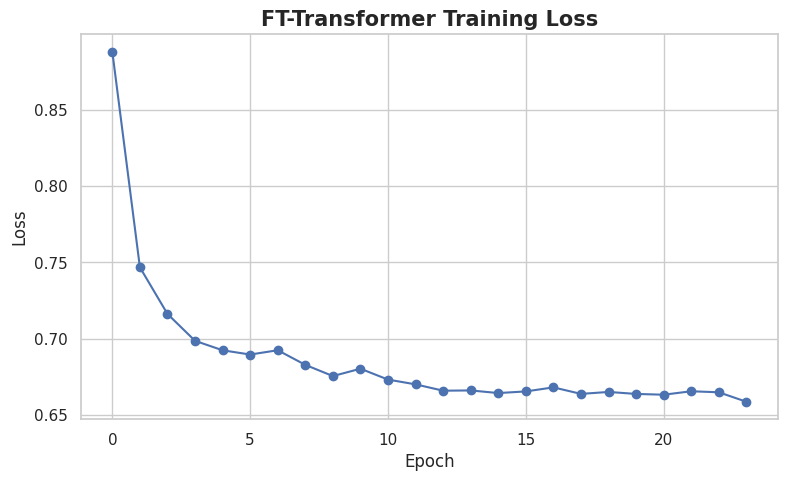

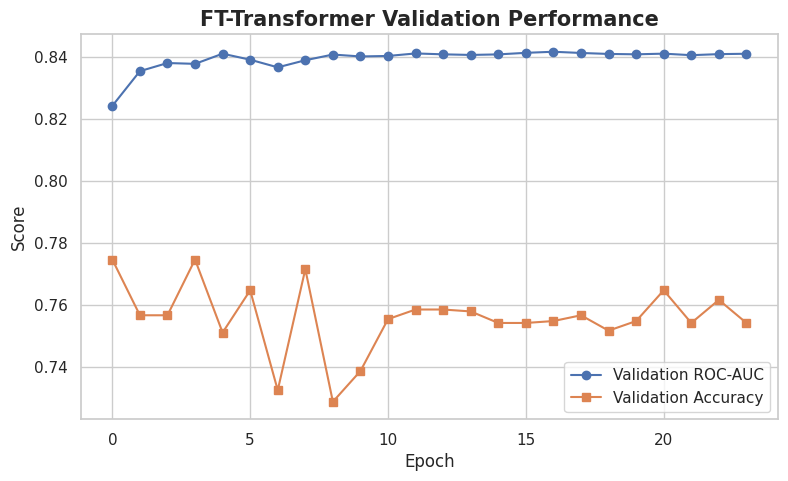

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.plot(train_losses, marker="o")
plt.title("FT-Transformer Training Loss", fontsize=15, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(val_aucs, marker="o", label="Validation ROC-AUC")
plt.plot(val_accuracies, marker="s", label="Validation Accuracy")
plt.title("FT-Transformer Validation Performance", fontsize=15, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

Evaluate Transformer on Test Set

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Safety check
print("Model type:", type(ft_transformer_model))

ft_transformer_model.eval()

with torch.no_grad():
    logits = ft_transformer_model(X_test_tensor.to(device))
    ft_probs = torch.sigmoid(logits).cpu().numpy().ravel()

ft_preds_default = (ft_probs >= 0.50).astype(int)

print("FT-Transformer Results at Threshold 0.50")
print("Accuracy:", accuracy_score(y_test, ft_preds_default))
print("Precision:", precision_score(y_test, ft_preds_default))
print("Recall:", recall_score(y_test, ft_preds_default))
print("F1-score:", f1_score(y_test, ft_preds_default))
print("ROC-AUC:", roc_auc_score(y_test, ft_probs))

print("\nClassification Report:")
print(classification_report(y_test, ft_preds_default))

Model type: <class '__main__.FTTransformer'>
FT-Transformer Results at Threshold 0.50
Accuracy: 0.7353525322740815
Precision: 0.5842558425584256
Recall: 0.7089552238805971
F1-score: 0.6405933917734322
ROC-AUC: 0.8103533670931059

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.75      0.79      1344
           1       0.58      0.71      0.64       670

    accuracy                           0.74      2014
   macro avg       0.71      0.73      0.72      2014
weighted avg       0.75      0.74      0.74      2014



Confusion Matrix

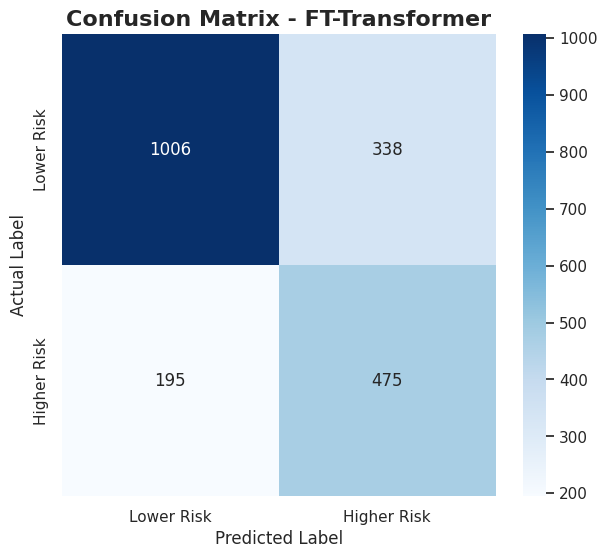

In [ ]:
import seaborn as sns

cm = confusion_matrix(y_test, ft_preds_default)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Lower Risk", "Higher Risk"],
    yticklabels=["Lower Risk", "Higher Risk"]
)

plt.title("Confusion Matrix - FT-Transformer", fontsize=16, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

Threshold Optimization

In [ ]:
thresholds = np.arange(0.10, 0.91, 0.01)

threshold_results = []

for threshold in thresholds:
    preds = (ft_probs >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, zero_division=0),
        "Recall": recall_score(y_test, preds, zero_division=0),
        "F1-score": f1_score(y_test, preds, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)

best_acc_row = threshold_df.sort_values("Accuracy", ascending=False).iloc[0]
best_f1_row = threshold_df.sort_values("F1-score", ascending=False).iloc[0]

print("Best threshold by Accuracy:")
display(best_acc_row)

print("Best threshold by F1-score:")
display(best_f1_row)

Best threshold by Accuracy:


,57
Threshold,0.670000
Accuracy,0.765641
Precision,0.678058
Recall,0.562687
F1-score,0.615008


Best threshold by F1-score:


,29
Threshold,0.390000
Accuracy,0.718967
Precision,0.552953
Recall,0.810448
F1-score,0.657385


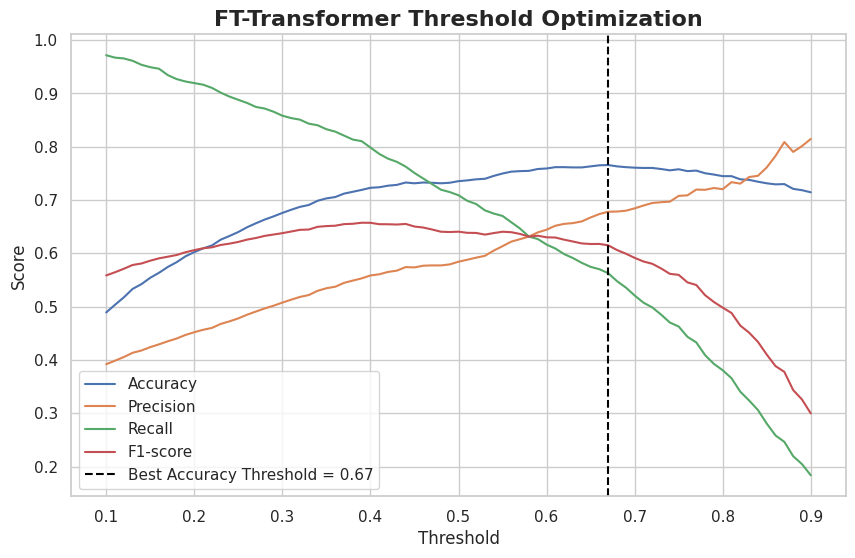

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(threshold_df["Threshold"], threshold_df["Accuracy"], label="Accuracy")
plt.plot(threshold_df["Threshold"], threshold_df["Precision"], label="Precision")
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], label="Recall")
plt.plot(threshold_df["Threshold"], threshold_df["F1-score"], label="F1-score")

plt.axvline(
    best_acc_row["Threshold"],
    linestyle="--",
    color="black",
    label=f"Best Accuracy Threshold = {best_acc_row['Threshold']:.2f}"
)

plt.title("FT-Transformer Threshold Optimization", fontsize=16, fontweight="bold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

Optimized Confusion Matrix

In [ ]:
best_threshold = best_acc_row["Threshold"]

ft_preds_optimized = (ft_probs >= best_threshold).astype(int)

print("FT-Transformer Optimized Results")
print("Best Threshold:", best_threshold)
print("Accuracy:", accuracy_score(y_test, ft_preds_optimized))
print("Precision:", precision_score(y_test, ft_preds_optimized, zero_division=0))
print("Recall:", recall_score(y_test, ft_preds_optimized, zero_division=0))
print("F1-score:", f1_score(y_test, ft_preds_optimized, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, ft_probs))

print("\nClassification Report:")
print(classification_report(y_test, ft_preds_optimized))

FT-Transformer Optimized Results
Best Threshold: 0.6699999999999997
Accuracy: 0.7656405163853028
Precision: 0.6780575539568345
Recall: 0.5626865671641791
F1-score: 0.6150081566068516
ROC-AUC: 0.8103533670931059

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.87      0.83      1344
           1       0.68      0.56      0.62       670

    accuracy                           0.77      2014
   macro avg       0.74      0.71      0.72      2014
weighted avg       0.76      0.77      0.76      2014



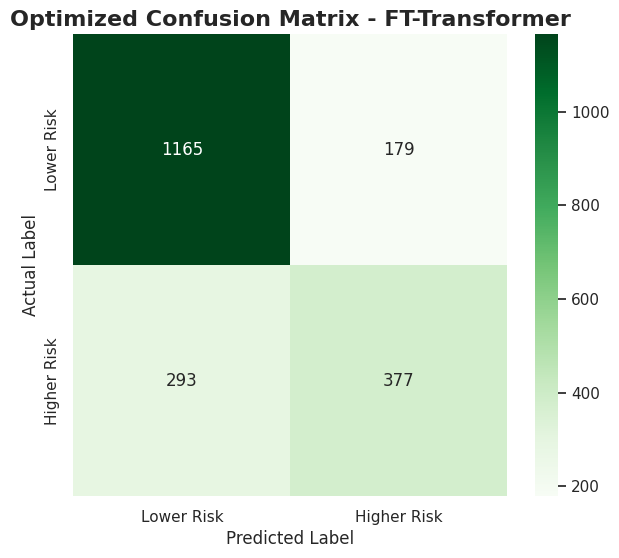

In [ ]:
cm_opt = confusion_matrix(y_test, ft_preds_optimized)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_opt,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Lower Risk", "Higher Risk"],
    yticklabels=["Lower Risk", "Higher Risk"]
)

plt.title("Optimized Confusion Matrix - FT-Transformer", fontsize=16, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

Compare Classical Models with Transformer

In [ ]:
classic_results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
2,Extra Trees,0.760675,0.658249,0.583582,0.618671,0.820939
4,CatBoost,0.756207,0.666048,0.535821,0.593879,0.820018
1,Random Forest,0.761668,0.666667,0.567164,0.612903,0.819216
3,LightGBM,0.758689,0.672932,0.534328,0.595674,0.818159
0,Logistic Regression,0.736346,0.586767,0.701493,0.639021,0.805777
5,SVM,0.744786,0.616418,0.616418,0.616418,0.797853


In [ ]:
ft_result = pd.DataFrame([{
    "Model": "FT-Transformer",
    "Accuracy": accuracy_score(y_test, ft_preds_optimized),
    "Precision": precision_score(y_test, ft_preds_optimized, zero_division=0),
    "Recall": recall_score(y_test, ft_preds_optimized, zero_division=0),
    "F1-score": f1_score(y_test, ft_preds_optimized, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, ft_probs)
}])

all_results_df = pd.concat([classic_results_df, ft_result], ignore_index=True)
all_results_df = all_results_df.sort_values("Accuracy", ascending=False)

display(all_results_df)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
6,FT-Transformer,0.765641,0.678058,0.562687,0.615008,0.810353
2,Random Forest,0.761668,0.666667,0.567164,0.612903,0.819216
0,Extra Trees,0.760675,0.658249,0.583582,0.618671,0.820939
3,LightGBM,0.758689,0.672932,0.534328,0.595674,0.818159
1,CatBoost,0.756207,0.666048,0.535821,0.593879,0.820018
5,SVM,0.744786,0.616418,0.616418,0.616418,0.797853
4,Logistic Regression,0.736346,0.586767,0.701493,0.639021,0.805777


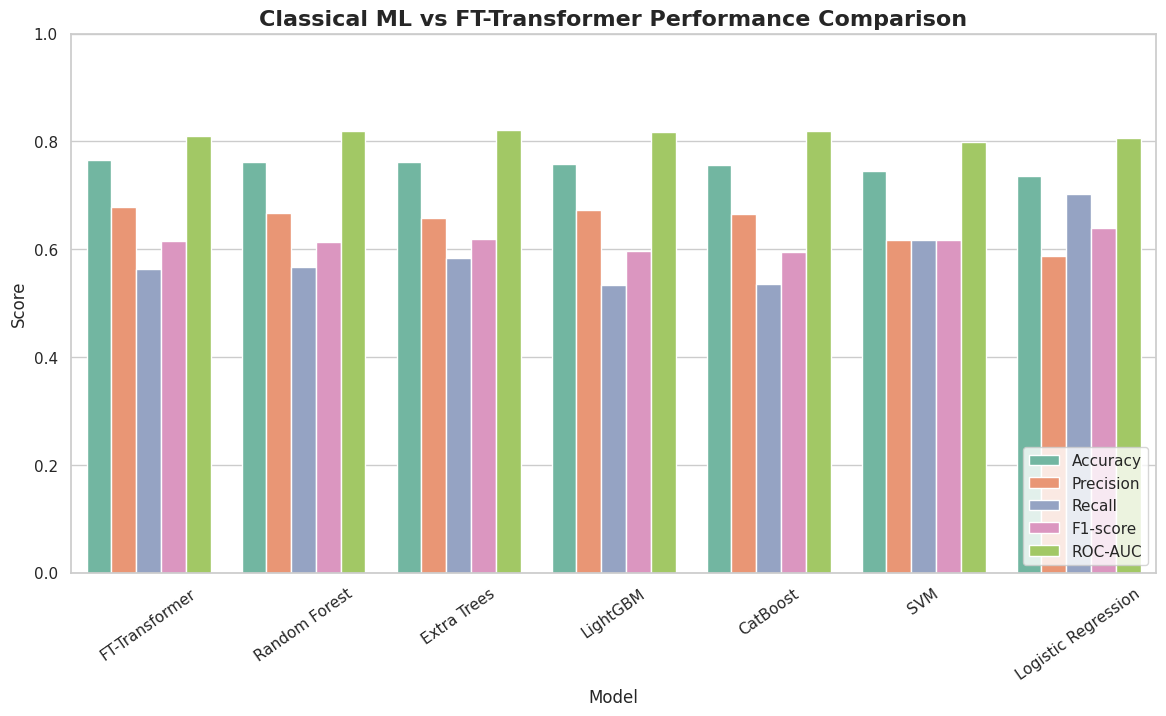

In [ ]:
melted_results = all_results_df.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(14, 7))
sns.barplot(
    data=melted_results,
    x="Model",
    y="Score",
    hue="Metric",
    palette="Set2"
)

plt.title("Classical ML vs FT-Transformer Performance Comparison", fontsize=16, fontweight="bold")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=35)
plt.legend(loc="lower right")
plt.show()

ROC Curve for Transformer

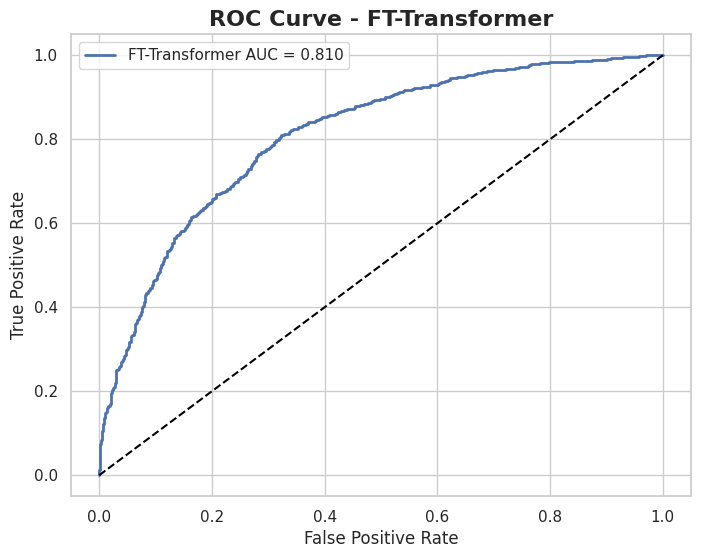

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, ft_probs)
auc_score = roc_auc_score(y_test, ft_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"FT-Transformer AUC = {auc_score:.3f}", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="black")

plt.title("ROC Curve - FT-Transformer", fontsize=16, fontweight="bold")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

SHAP for Transformer

In [ ]:
import shap

def ft_predict_proba(input_numpy):
    ft_transformer_model.eval()

    input_tensor = torch.tensor(input_numpy, dtype=torch.float32).to(device)

    with torch.no_grad():
        logits = ft_transformer_model(input_tensor)
        probs = torch.sigmoid(logits).cpu().numpy().ravel()

    return probs

In [ ]:
background_size = min(50, X_tr_np.shape[0])
explain_size = min(50, X_test_np.shape[0])

np.random.seed(42)

background_idx = np.random.choice(X_tr_np.shape[0], background_size, replace=False)
explain_idx = np.random.choice(X_test_np.shape[0], explain_size, replace=False)

X_background = X_tr_np[background_idx]
X_explain = X_test_np[explain_idx]

X_explain_df = pd.DataFrame(X_explain, columns=X.columns)

print("Background shape:", X_background.shape)
print("Explain shape:", X_explain.shape)

Background shape: (50, 122)
Explain shape: (50, 122)


In [ ]:
ft_shap_explainer = shap.KernelExplainer(ft_predict_proba, X_background)

ft_shap_values = ft_shap_explainer.shap_values(
    X_explain,
    nsamples=100
)

  0%|          | 0/50 [00:00<?, ?it/s]

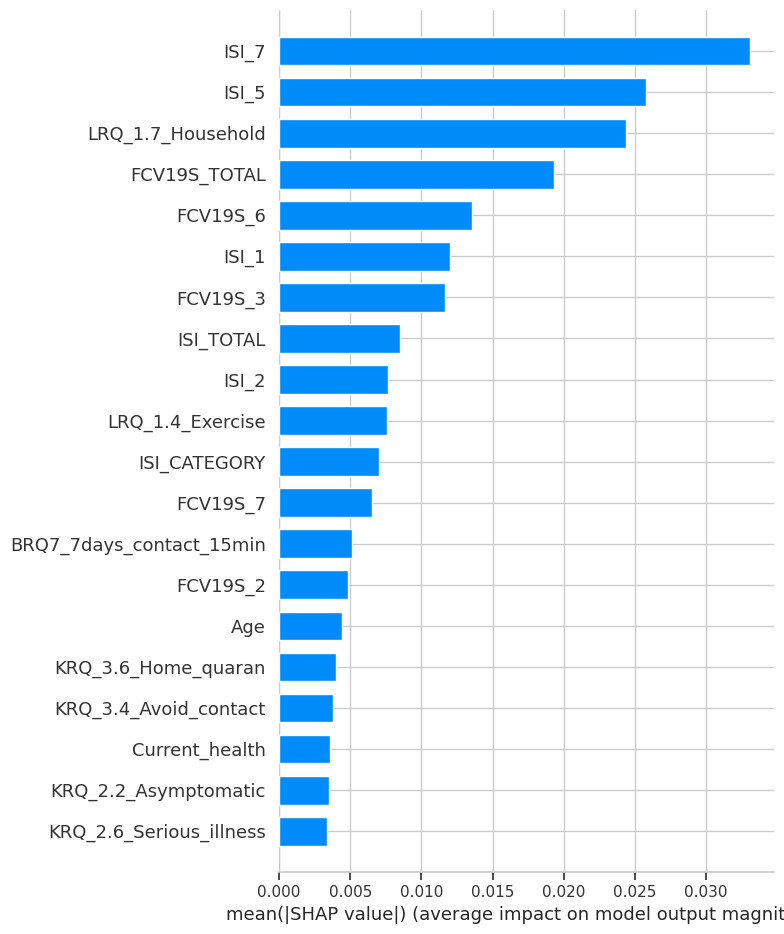

In [ ]:
shap.summary_plot(
    ft_shap_values,
    X_explain_df,
    plot_type="bar",
    max_display=20
)

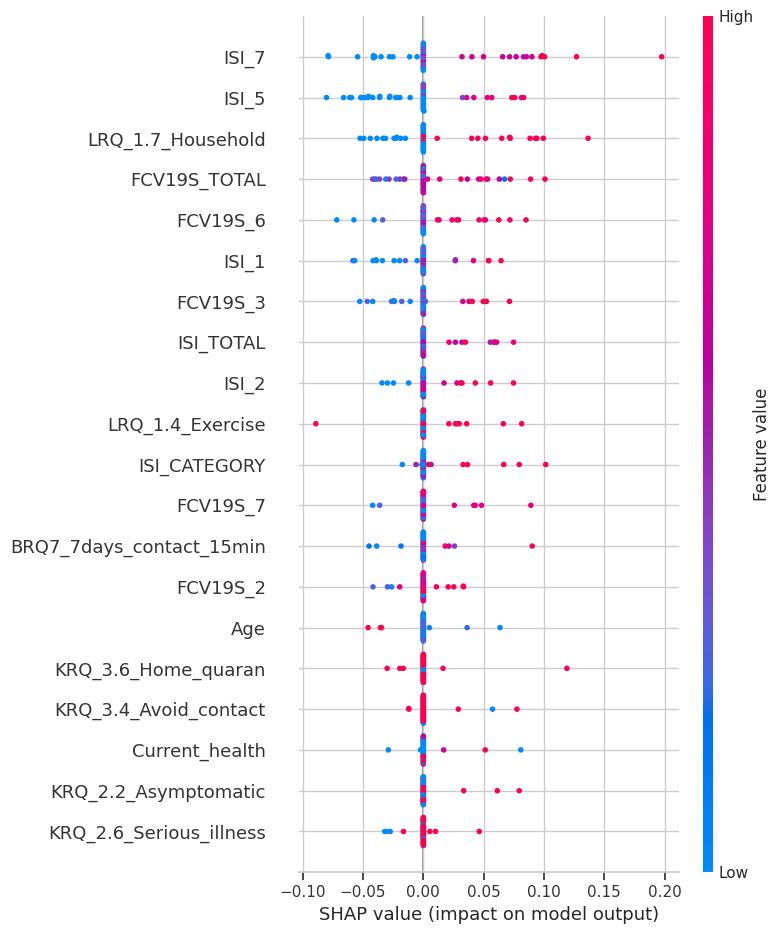

In [ ]:
shap.summary_plot(
    ft_shap_values,
    X_explain_df,
    plot_type="dot",
    max_display=20
)

Save Results

In [ ]:
all_results_df.to_csv("classical_vs_ft_transformer_results.csv", index=False)
threshold_df.to_csv("ft_transformer_threshold_results.csv", index=False)

torch.save(ft_transformer_model.state_dict(), "ft_transformer_model.pt")

print("Saved:")
print("classical_vs_ft_transformer_results.csv")
print("ft_transformer_threshold_results.csv")
print("ft_transformer_model.pt")

Saved:
classical_vs_ft_transformer_results.csv
ft_transformer_threshold_results.csv
ft_transformer_model.pt


In [ ]:
from google.colab import files

files.download("classical_vs_ft_transformer_results.csv")
files.download("ft_transformer_threshold_results.csv")
files.download("ft_transformer_model.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>